In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces


In [3]:
faces=fetch_olivetti_faces()
X=faces.data
y=faces.target
print(X.shape)
print(y.shape)


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\surya\scikit_learn_data
(400, 4096)
(400,)


Text(0.5, 1.0, 'Person0')

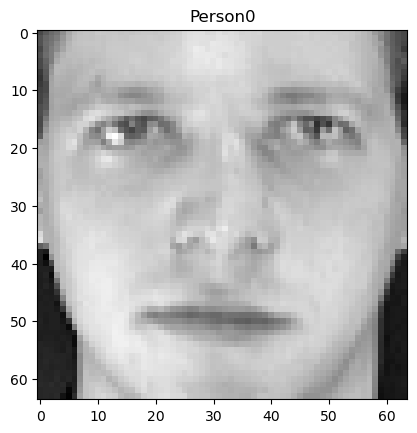

In [5]:
#400 images,4096 features
plt.imshow(faces.images[0],
          cmap='gray')
plt.title(f"Person{y[0]}")

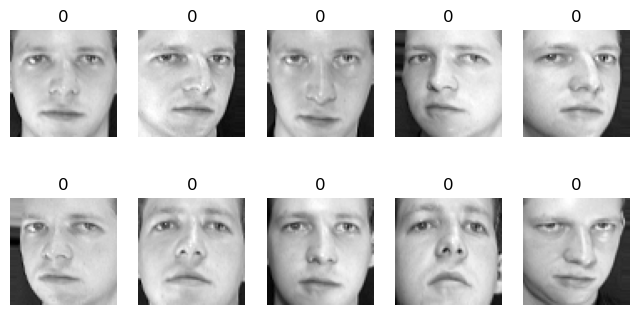

In [40]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(8,4))
for i,ax in enumerate(axes.ravel()):
    ax.imshow(
        faces.images[i],
        cmap='gray'
        )
    ax.set_title(y[i])
    ax.axis("off")
    
plt.show()

In [12]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.9)
X_pca=pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(400, 4096)
(400, 66)


In [13]:
print(sum(pca.explained_variance_ratio_))

0.9002452


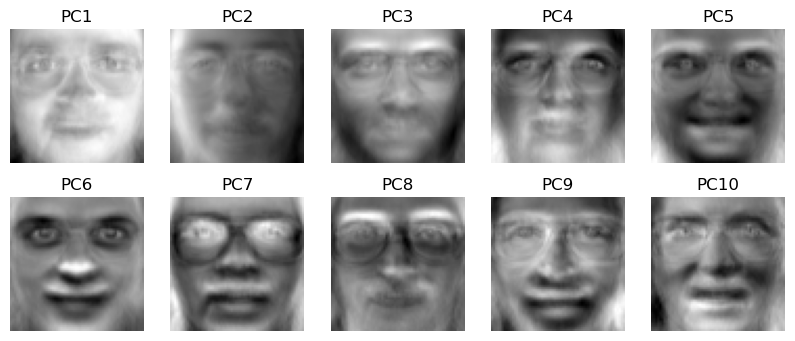

In [14]:
#4096 to 66 features and EVR is 0.9
fig, axes = plt.subplots(
    2, 5,
    figsize=(10,4)
)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(
        pca.components_[i].reshape(64,64),
        cmap="gray"
    )
    ax.set_title(
        f"PC{i+1}"
    )
    ax.axis("off")
plt.show()

In [15]:
sample=X[0]
sample_pca=pca.transform(
    sample.reshape(1,-1)
)
recons=pca.inverse_transform(
    sample_pca
)

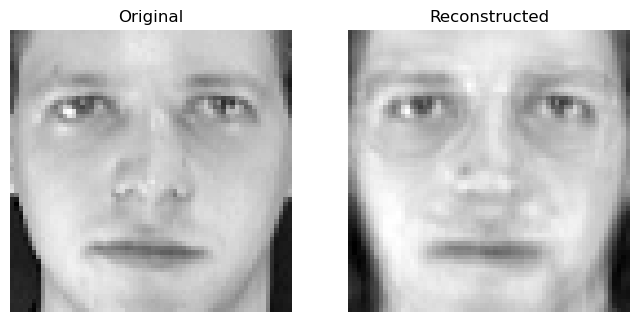

In [27]:
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(
    faces.images[0].reshape(64,64),
    cmap="gray"
)
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(
    recons.reshape(64,64),
    cmap="gray"
)
ax[1].set_title("Reconstructed")
ax[1].axis("off")
plt.show()

Text(0.5, 1.0, 'Damaged Image')

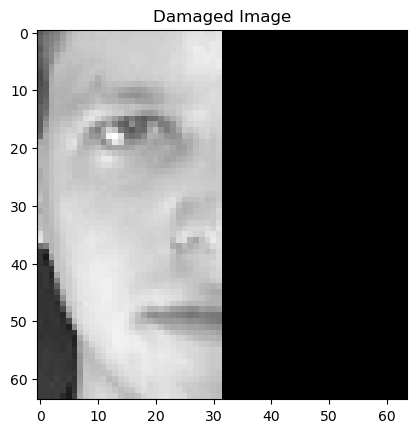

In [32]:
face=X[0].copy()
damaged=face.reshape(64,64)
damaged[:,32:]=0
plt.imshow(damaged,cmap='gray')
plt.title("Damaged Image")

In [30]:
damaged_flat=damaged.reshape(1,-1)

In [31]:
damaged_pca=pca.transform(damaged_flat)
recons=pca.inverse_transform(damaged_pca)

Text(0.5, 1.0, 'Reconstructed after damaging')

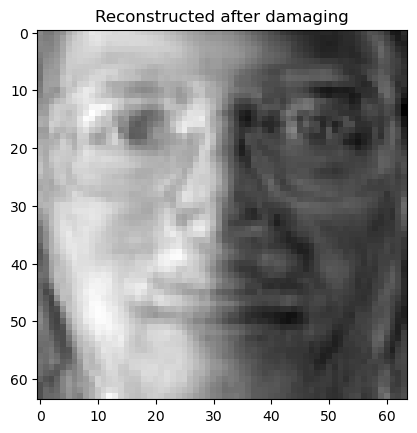

In [35]:
plt.imshow(recons.reshape(64,64),cmap='gray')
plt.title("Reconstructed after damaging")